In [1]:
import numpy as np
from scipy.ndimage import laplace, sobel, gaussian_filter, uniform_filter
from matplotlib import rc
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import ListedColormap
rc("font", family="serif")
rc("pgf", texsystem="pdflatex")
rc("text", usetex=True)
# rc('text.latex', unicode=True)
rc("text.latex", preamble=r"\usepackage{amssymb}")
rc("text.latex", preamble=r"\usepackage[T1,T2A]{fontenc}")
rc("text.latex", preamble=r"\usepackage[utf8]{inputenc}")
rc("text.latex", preamble=r"\usepackage[english,russian]{babel}")
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.colors import ListedColormap
from config import setup_model_and_geometry
from config import PATH_DATA_DSUB, TMAX

In [2]:
model1, model2, dataset, velmodel, eik1, eik2, field1, field2 = setup_model_and_geometry(path_data=PATH_DATA_DSUB)

Operator `initdamp` ran in 0.01 s
Operator `initdamp` ran in 0.01 s


(<Figure size 1000x2000 with 1 Axes>,
 [<Axes: title={'center': 'Модель скорости продольных волн'}, xlabel='Расстояние, м', ylabel='Абс. отм., м'>])

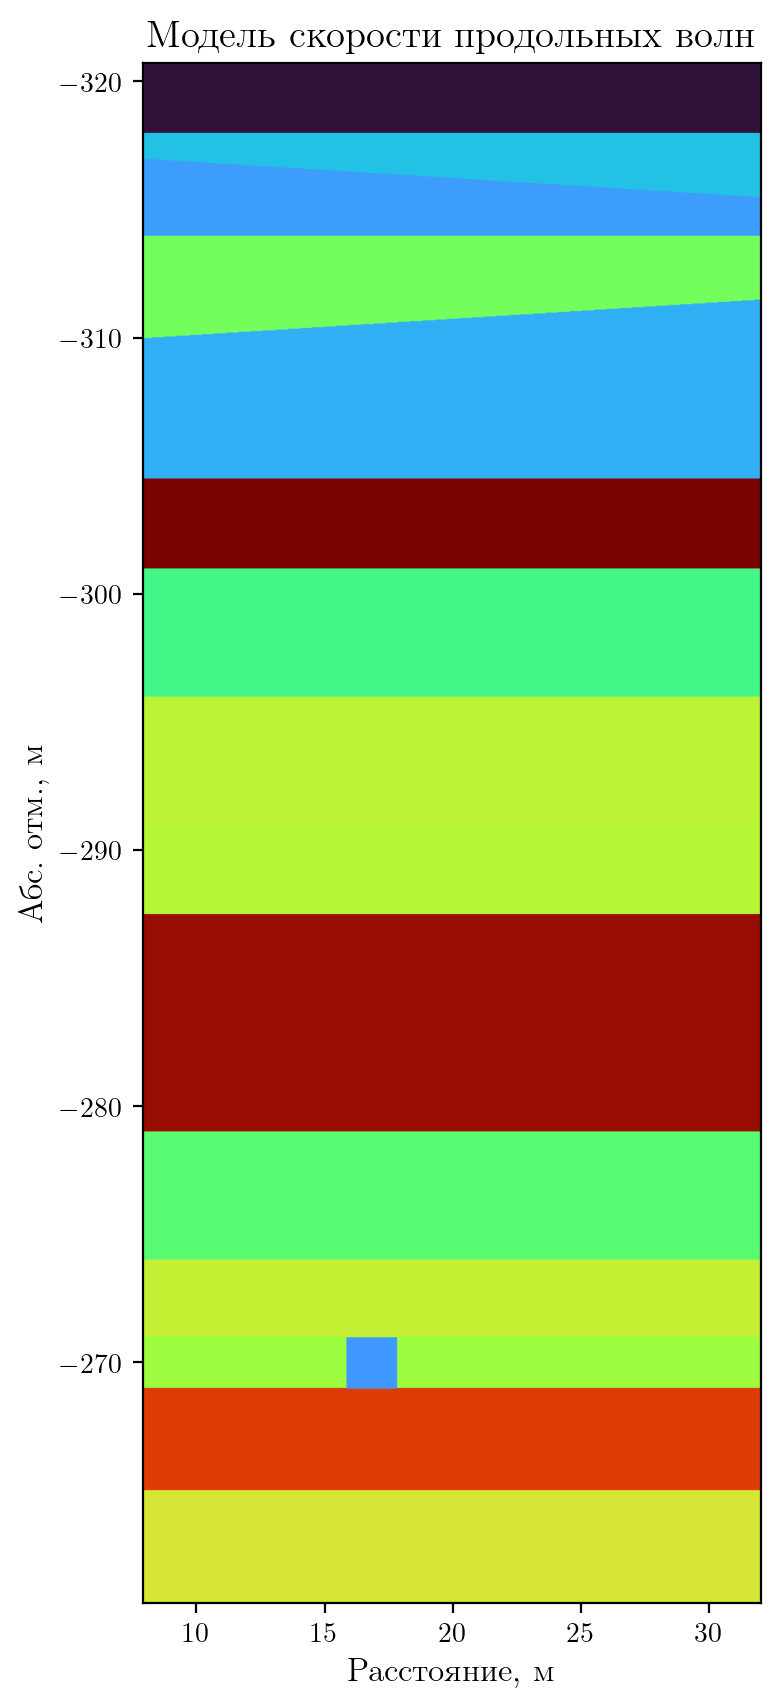

In [3]:
velmodel.plot_vp()

In [4]:
_, sx, sz, _, rec_z = dataset[10]
print(sx, sz)

10.76 -304.98


In [5]:
815//5 + 1

164

In [6]:
1980//5 + 1

397

In [7]:
velmodel._current_model["vel"].shape

(2005, 805)

In [8]:
np.array(model1.vp.data[500:-500, 500:-500]).T.shape

(2005, 805)

In [9]:
print(field2.shape)
galsnap = np.load("gal/snap_10.npy")
nogalsnap = np.load("nogal/snap_10.npy")

(2005, 805)


In [10]:
_, sx, sz, _, rec_z = dataset[9]

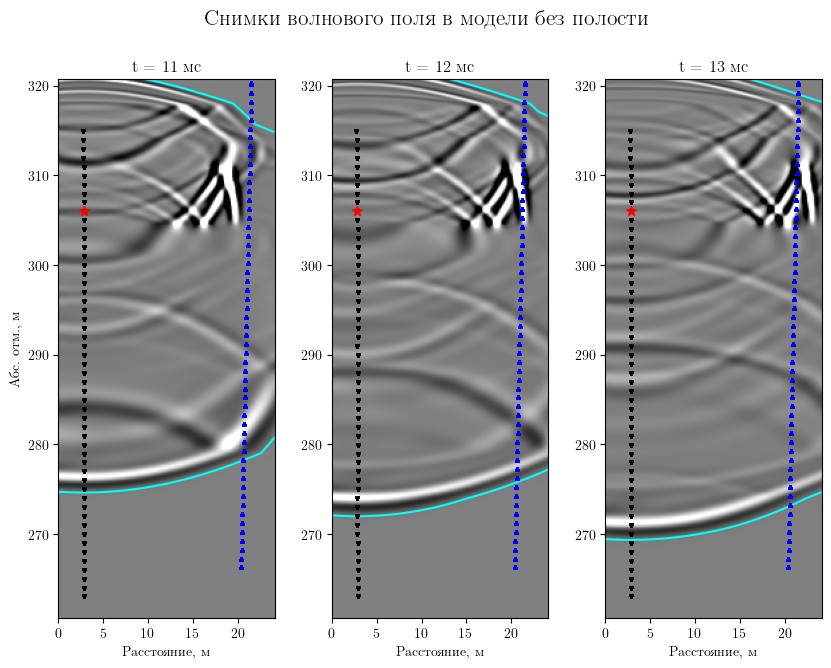

In [18]:
fig, axs = plt.subplots(1, 3, figsize=(10, 7.0))

levels = [11, 12, 13]*2
snaps = [nogalsnap[int(el/35*500)] for el in levels[:3]] + [galsnap[int(el/35*500)] for el in levels[:3]]
titles = [f"t = {el} мс" for el in levels]
fig.suptitle("Снимки волнового поля в модели без полости", fontsize=16)
# plt.text(0.315, 0.92, "В модели без полости", color='k', fontsize=14, transform=fig.transFigure, ha='center', va='center')
# plt.text(0.713, 0.92, "В модели с полостью", color='k', fontsize=14, transform=fig.transFigure, ha='center', va='center')
qa = np.quantile(snaps, 0.99)
axs[0].set_ylabel("Абс. отм., м")

for i in range(3):
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Расстояние, м")
    axs[i].scatter(dataset.x_coords-velmodel.x[0], -dataset.elevations, c='k', s=5, marker='v', zorder=50)
    axs[i].scatter(dataset.opposite_x-velmodel.x[0], -dataset.opposite_elev, c='b', s=5, marker='^', zorder=50)

for i in range(3):
    axs[i].imshow(snaps[i].T, cmap='gray', extent=[velmodel.x[0]-velmodel.x[0], velmodel.x[-1]-velmodel.x[0], -velmodel.z[-1], -velmodel.z[0]], vmin=-qa, vmax=qa, aspect='equal')
    axs[i].contour(np.flip(field1, axis=0), levels=[levels[i]], extent=[velmodel.x[0]-velmodel.x[0], velmodel.x[-1]-velmodel.x[0], -velmodel.z[-1], -velmodel.z[0]], colors='cyan')
    axs[i].scatter(sx-velmodel.x[0], -sz, marker='*', s=50, c='r', zorder=100)

# for i in range(3, 6):
#     axs[i].imshow(snaps[i].T, cmap='gray', extent=[velmodel.x[0]-velmodel.x[0], velmodel.x[-1]-velmodel.x[0], -velmodel.z[-1], -velmodel.z[0]], vmin=-qa, vmax=qa, aspect='equal')
#     axs[i].contour(np.flip(field2, axis=0), levels=[levels[i]], extent=[velmodel.x[0]-velmodel.x[0], velmodel.x[-1]-velmodel.x[0], -velmodel.z[-1], -velmodel.z[0]], colors='cyan')
#     axs[i].scatter(sx-velmodel.x[0], -sz, marker='*', s=50, c='r', zorder=100)
#     axs[i].arrow(13, 281+(i-3)/10, -2, -2, color='red', head_width=1, head_length=2, width=0.5)
#     # axs[i].imshow()

plt.savefig('Figure 6_2.png', dpi=600, bbox_inches='tight')

plt.show()

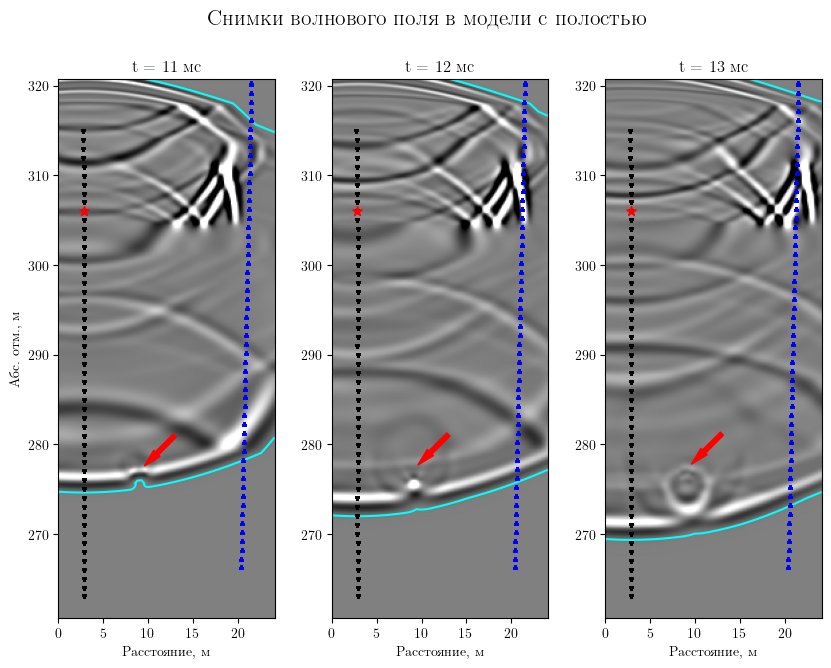

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(10, 7.0))

levels = [11, 12, 13]*2
snaps = [nogalsnap[int(el/35*500)] for el in levels[:3]] + [galsnap[int(el/35*500)] for el in levels[:3]]
titles = [f"t = {el} мс" for el in levels]
fig.suptitle("Снимки волнового поля в модели c полостью", fontsize=16)
# plt.text(0.315, 0.92, "В модели без полости", color='k', fontsize=14, transform=fig.transFigure, ha='center', va='center')
# plt.text(0.713, 0.92, "В модели с полостью", color='k', fontsize=14, transform=fig.transFigure, ha='center', va='center')
qa = np.quantile(snaps, 0.99)
axs[0].set_ylabel("Абс. отм., м")

for i in range(3):
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Расстояние, м")
    axs[i].scatter(dataset.x_coords-velmodel.x[0], -dataset.elevations, c='k', s=5, marker='v', zorder=50)
    axs[i].scatter(dataset.opposite_x-velmodel.x[0], -dataset.opposite_elev, c='b', s=5, marker='^', zorder=50)

# for i in range(3):
#     axs[i].imshow(snaps[i].T, cmap='gray', extent=[velmodel.x[0]-velmodel.x[0], velmodel.x[-1]-velmodel.x[0], -velmodel.z[-1], -velmodel.z[0]], vmin=-qa, vmax=qa, aspect='equal')
#     axs[i].contour(np.flip(field1, axis=0), levels=[levels[i]], extent=[velmodel.x[0]-velmodel.x[0], velmodel.x[-1]-velmodel.x[0], -velmodel.z[-1], -velmodel.z[0]], colors='cyan')
#     axs[i].scatter(sx-velmodel.x[0], -sz, marker='*', s=50, c='r', zorder=100)

for i in range(3):
    axs[i].imshow(snaps[i+3].T, cmap='gray', extent=[velmodel.x[0]-velmodel.x[0], velmodel.x[-1]-velmodel.x[0], -velmodel.z[-1], -velmodel.z[0]], vmin=-qa, vmax=qa, aspect='equal')
    axs[i].contour(np.flip(field2, axis=0), levels=[levels[i]], extent=[velmodel.x[0]-velmodel.x[0], velmodel.x[-1]-velmodel.x[0], -velmodel.z[-1], -velmodel.z[0]], colors='cyan')
    axs[i].scatter(sx-velmodel.x[0], -sz, marker='*', s=50, c='r', zorder=100)
    axs[i].arrow(13, 281+(i)/10, -2, -2, color='red', head_width=1, head_length=2, width=0.5)
    # axs[i].imshow()

plt.savefig('Figure 6_3.png', dpi=600, bbox_inches='tight')

plt.show()

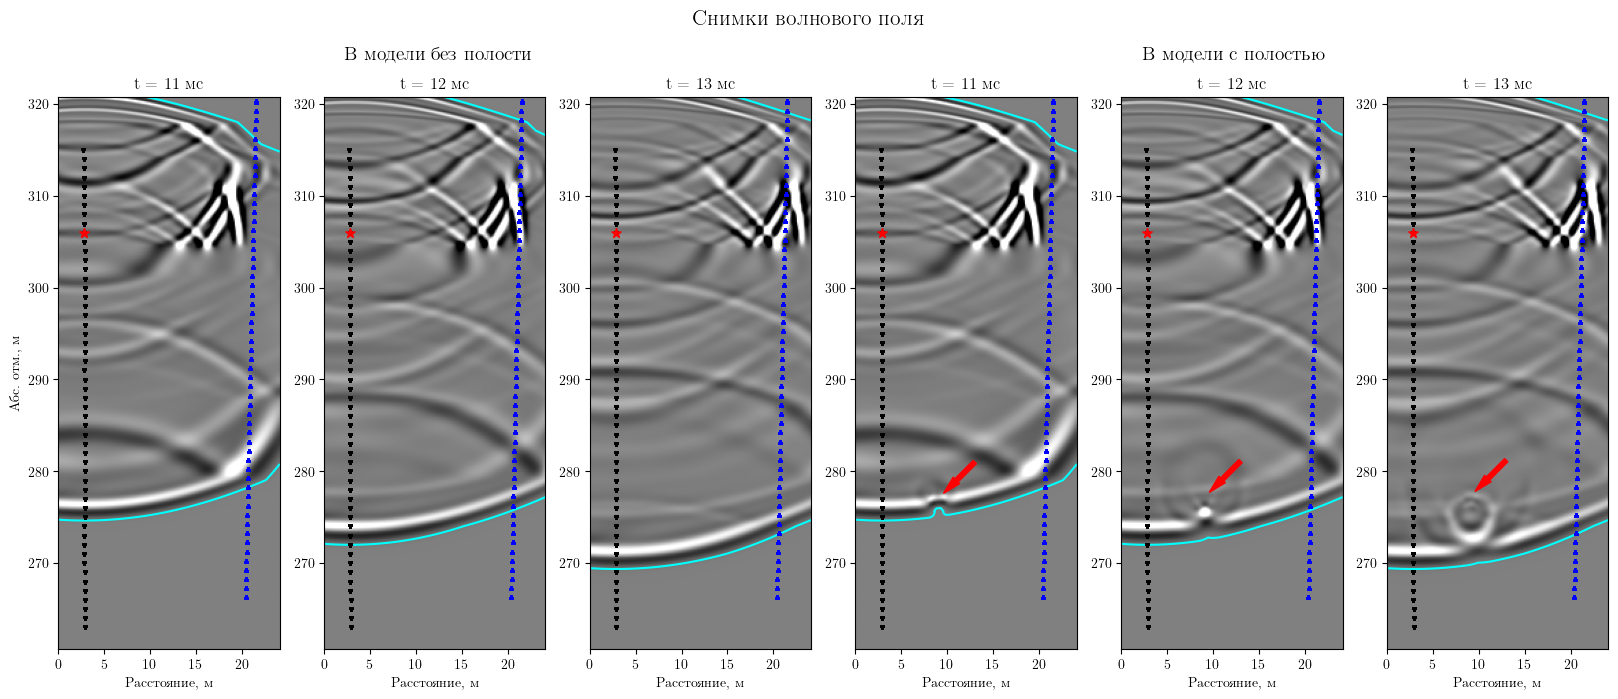

In [ ]:
fig, axs = plt.subplots(1, 6, figsize=(20, 7.5))

levels = [11, 12, 13]*2
snaps = [nogalsnap[int(el/35*500)] for el in levels[:3]] + [galsnap[int(el/35*500)] for el in levels[:3]]
titles = [f"t = {el} мс" for el in levels]
fig.suptitle("Снимки волнового поля", fontsize=16)
plt.text(0.315, 0.92, "В модели без полости", color='k', fontsize=14, transform=fig.transFigure, ha='center', va='center')
plt.text(0.713, 0.92, "В модели с полостью", color='k', fontsize=14, transform=fig.transFigure, ha='center', va='center')
qa = np.quantile(snaps, 0.99)
axs[0].set_ylabel("Абс. отм., м")

for i in range(6):
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Расстояние, м")
    axs[i].scatter(dataset.x_coords-velmodel.x[0], -dataset.elevations, c='k', s=5, marker='v', zorder=50)
    axs[i].scatter(dataset.opposite_x-velmodel.x[0], -dataset.opposite_elev, c='b', s=5, marker='^', zorder=50)

for i in range(3):
    axs[i].imshow(snaps[i].T, cmap='gray', extent=[velmodel.x[0]-velmodel.x[0], velmodel.x[-1]-velmodel.x[0], -velmodel.z[-1], -velmodel.z[0]], vmin=-qa, vmax=qa, aspect='equal')
    axs[i].contour(np.flip(field1, axis=0), levels=[levels[i]], extent=[velmodel.x[0]-velmodel.x[0], velmodel.x[-1]-velmodel.x[0], -velmodel.z[-1], -velmodel.z[0]], colors='cyan')
    axs[i].scatter(sx-velmodel.x[0], -sz, marker='*', s=50, c='r', zorder=100)

for i in range(3, 6):
    axs[i].imshow(snaps[i].T, cmap='gray', extent=[velmodel.x[0]-velmodel.x[0], velmodel.x[-1]-velmodel.x[0], -velmodel.z[-1], -velmodel.z[0]], vmin=-qa, vmax=qa, aspect='equal')
    axs[i].contour(np.flip(field2, axis=0), levels=[levels[i]], extent=[velmodel.x[0]-velmodel.x[0], velmodel.x[-1]-velmodel.x[0], -velmodel.z[-1], -velmodel.z[0]], colors='cyan')
    axs[i].scatter(sx-velmodel.x[0], -sz, marker='*', s=50, c='r', zorder=100)
    axs[i].arrow(13, 281+(i-3)/10, -2, -2, color='red', head_width=1, head_length=2, width=0.5)
    # axs[i].imshow()


plt.show()

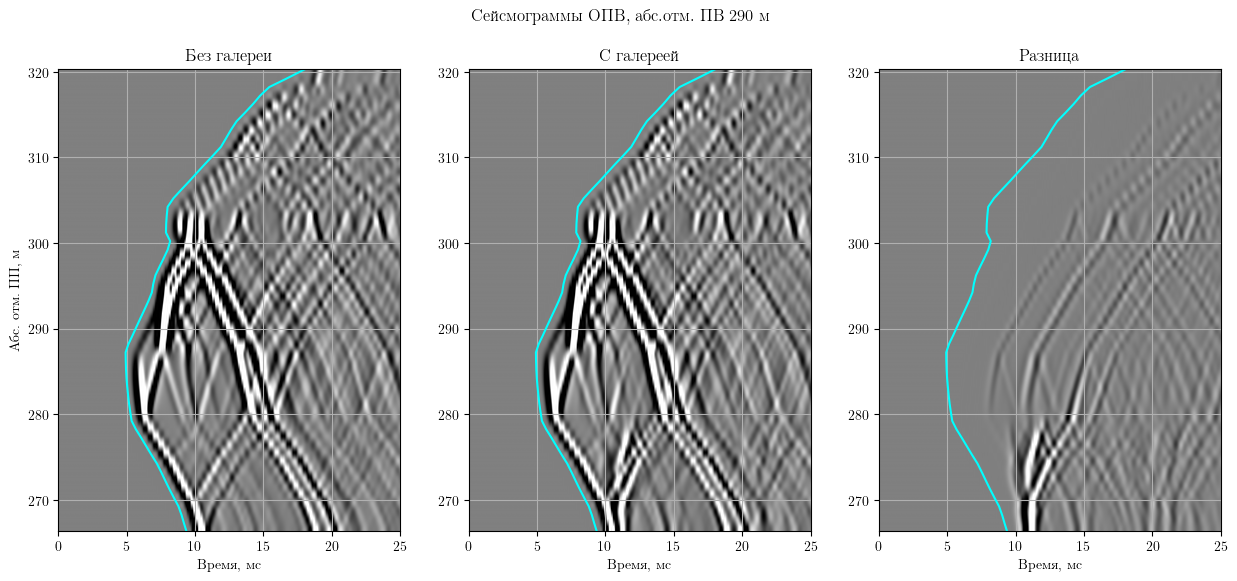

In [ ]:
nogal = np.load("nogal/gather_26.npy")
gal = np.load("gal/gather_26.npy")
hod = np.load("hods/hods_26.npy")
qa = np.quantile(gal, 0.985)

fig, axs = plt.subplots(1, 3, figsize=(15, 6))
axs[0].imshow(nogal.T, aspect='auto', vmin=-qa, vmax=qa, extent=[-dataset.opposite_elev.min(), -dataset.opposite_elev.max(), TMAX, 0][::-1], cmap='gray', interpolation='spline36')
axs[0].plot(hod[:, -2], -rec_z, c='cyan')
axs[1].imshow(gal.T, aspect='auto', vmin=-qa, vmax=qa, extent=[-dataset.opposite_elev.min(), -dataset.opposite_elev.max(), TMAX, 0][::-1], cmap='gray', interpolation='spline36')
axs[1].plot(hod[:, -1], -rec_z, c='cyan')
axs[2].imshow(gal.T-nogal.T, aspect='auto', vmin=-qa, vmax=qa, extent=[-dataset.opposite_elev.min(), -dataset.opposite_elev.max(), TMAX, 0][::-1], cmap='gray', interpolation='spline36')
axs[2].plot(hod[:, -1], -rec_z, c='cyan')
fig.suptitle(f"Сейсмограммы ОПВ, абс.отм. ПВ 290 м")
titles = ["Без галереи", "С галереей", "Разница"]
for ax, ti in zip(axs, titles):
    # ax.plot(rec_z, hodograph2)

    ax.grid()
    ax.set_xlim([0, 25])
    ax.set_title(ti)
    ax.set_xlabel("Время, мс")

axs[0].set_ylabel("Абс. отм. ПП, м")
plt.savefig('CSG comparison.png', dpi=600, bbox_inches='tight')
plt.show()

In [63]:
print(hod[:, -2] - hod[:, -1])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]


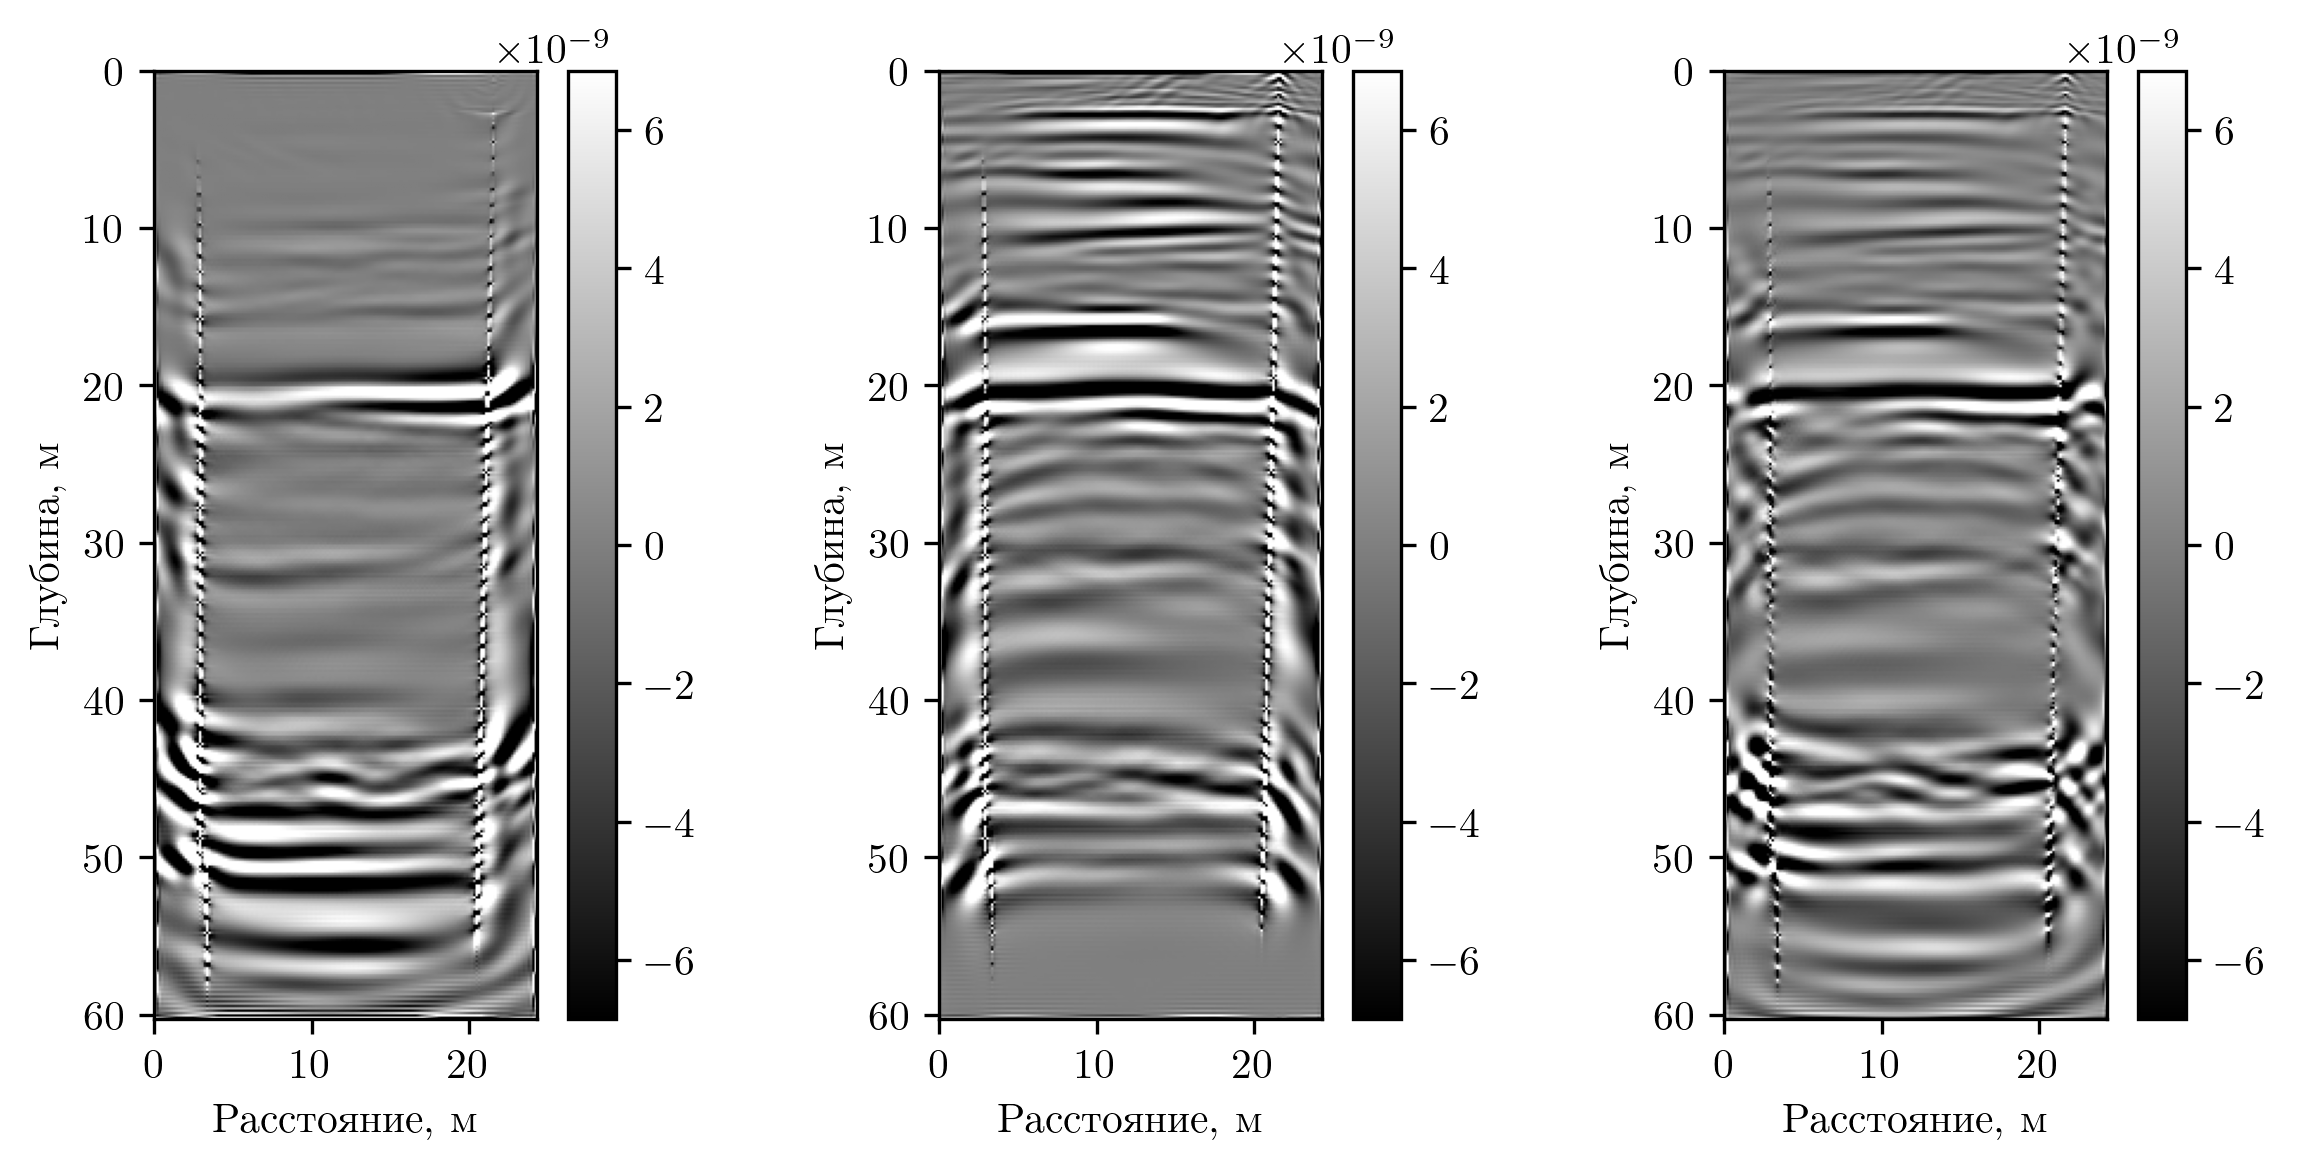

In [12]:
from config import NBL
grad_u0 = np.load("gradients/grad_full_u_0.npy")
grad_d0 = np.load("gradients/grad_full_d_0.npy")

# magnitude[magnitude] = np.nan
fig, axs = plt.subplots(1, 3, figsize=(8, 4), dpi=300)
# glmax = max([np.max(np.abs(grad_d)), np.max(np.abs(grad_u))])
glmax = max([np.quantile(grad_d0, 0.9), np.quantile(grad_u0, 0.9)])
# imag0 = grad_u0-grad_d0
imag0 = np.load("images/image_iter_2.npy")[::5, ::5]
for gr, ax in zip([grad_d0, grad_u0, imag0], axs):
    # h=ax.imshow(np.diff(gr.T, axis=0, n=2), cmap='gray', vmin=-glmax/5, vmax=glmax/5)
    # h=ax.imshow(-np.diff(gaussian_filter(gr.T, sigma=0), axis=0, n=1), cmap='gray', vmin=-glmax/2.5*3e3, vmax=glmax/2.5*3e3, extent=[0, grad_d0.shape[0]*0.03*5, grad_d0.shape[1]*0.03*5, 0])

    # h=ax.imshow(laplace(gr.T), cmap='gray', vmin=-glmax/5, vmax=glmax/5, extent=[0, grad_d0.shape[0]*0.25, grad_d0.shape[1]*0.25, 0])
    # h=ax.imshow(laplace(gaussian_filter(gr.T, sigma=0.9)), vmin=-glmax/3, vmax=glmax/3, cmap='gray', extent=[0, grad_d0.shape[0]*0.25, grad_d0.shape[1]*0.25, 0])
    # h=ax.imshow(np.diff(uniform_filter(gr.T, size=[5, 5]), axis=0, n=2), vmin=-glmax/10, vmax=glmax/10, cmap='gray', extent=[0, grad_d0.shape[0]*0.25, grad_d0.shape[1]*0.25, 0])

    h=ax.imshow(laplace(gr.T),
                vmin=-glmax/5, vmax=glmax/5,
                cmap='gray', extent=[0, grad_d0.shape[0]*0.03*5, grad_d0.shape[1]*0.03*5, 0])
    #hh=ax.imshow(model.vp.data[NBL:-NBL, NBL:-NBL].T, cmap='jet', vmin=0.5, vmax=5.5, alpha=0.3, extent=[0, grad_d0.shape[0]*0.03*5, grad_d0.shape[1]*0.03*5, 0])
    ax.set_xlabel("Расстояние, м")
    ax.set_ylabel("Глубина, м")

    fig.colorbar(h)



plt.tight_layout()
plt.show()